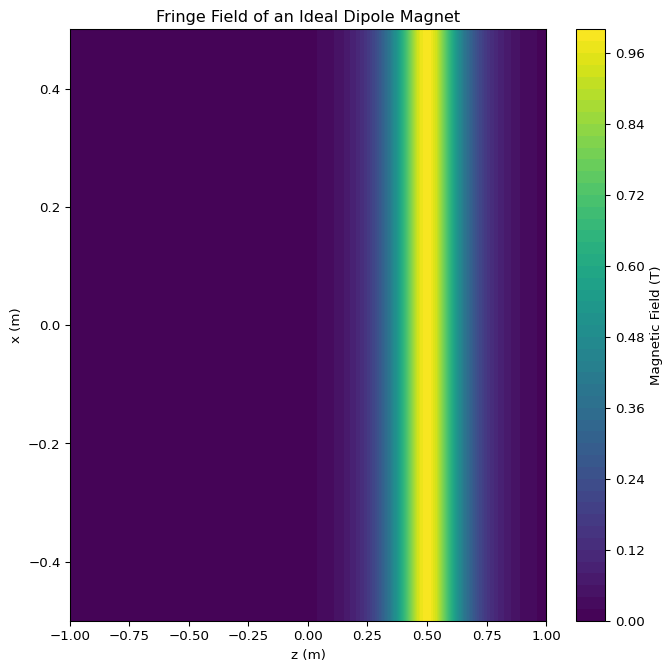

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
B0 = 1.0  # Central field strength (Tesla)
z0 = 0.5   # Edge of the magnet (meters)
a = 0.1    # Decay length (meters)

# Grid
z = np.linspace(-1, 1, 100)
x = np.linspace(-0.5, 0.5, 100)
Z, X = np.meshgrid(z, x)

# Fringe field approximation
Bx = B0 / np.cosh((Z - z0) / a)

# Plot
plt.figure()
plt.contourf(Z, X, Bx, levels=50, cmap='viridis')
plt.colorbar(label='Magnetic Field (T)')
plt.xlabel('z (m)')
plt.ylabel('x (m)')
plt.title('Fringe Field of an Ideal Dipole Magnet')
plt.show()

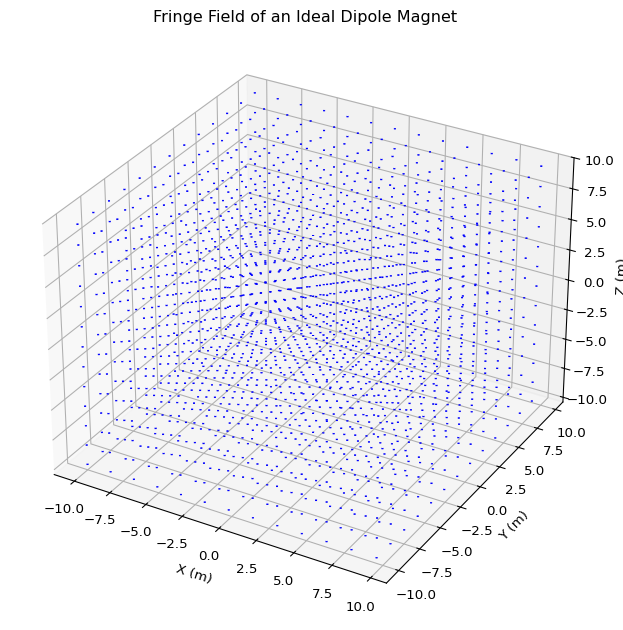

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d

# Parameters
B0 = 1.0  # Central field strength (Tesla)
z0 = 0.5  # Edge of the magnet (meters)
a = 0.1   # Decay length (meters)

# Create a 3D grid
x = np.linspace(-10, 10, 50)
y = np.linspace(-10, 10, 50)
z = np.linspace(-10, 10, 50)
X, Y, Z = np.meshgrid(x, y, z)

# Fringe field approximation
# Assume the magnet is aligned along the z-axis
# Bx and By are small compared to Bz in the fringe region
Bx = B0 * np.exp(-((Z - z0) / a)**2) * (X / np.sqrt(X**2 + Y**2 + 1e-10))
By = B0 * np.exp(-((Z - z0) / a)**2) * (Y / np.sqrt(X**2 + Y**2 + 1e-10))
Bz = B0 / np.cosh((Z - z0) / a)

# Normalize the field components for visualization
Bx = Bx / np.max(np.abs(Bx))
By = By / np.max(np.abs(By))
Bz = Bz / np.max(np.abs(Bz))

# Plot the 3D field (quiver plot)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plot a subset of points for clarity
skip = 4  # Skip points to reduce clutter
ax.quiver(X[::skip, ::skip, ::skip], Y[::skip, ::skip, ::skip], Z[::skip, ::skip, ::skip],
          Bx[::skip, ::skip, ::skip], By[::skip, ::skip, ::skip], Bz[::skip, ::skip, ::skip],
          length=0.1, normalize=True, color='b')

ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.set_title('Fringe Field of an Ideal Dipole Magnet')
plt.show()